In [1]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
df = pd.read_csv(r"models\processed_data.csv")
X = df.drop(columns=['Churn'])
y = df['Churn']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Class Distribution in Training Data: {0.0: 9628, 1.0: 2022}


C:\Users\sindh\AppData\Local\Temp\ipykernel_13888\1376378734.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette=["blue", "red"])


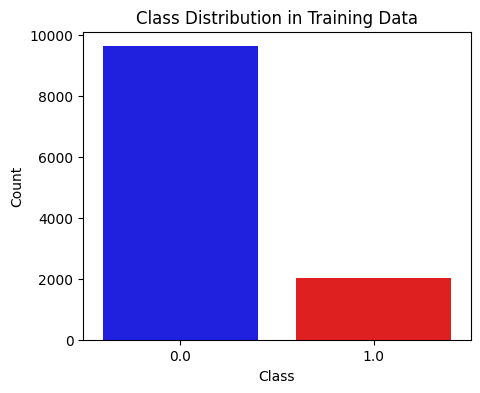

In [4]:
unique, counts = np.unique(y_train, return_counts=True)
print("Class Distribution in Training Data:", dict(zip(unique, counts)))
plt.figure(figsize=(5, 4))
sns.barplot(x=unique, y=counts, palette=["blue", "red"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution in Training Data")
plt.show()

In [5]:
smote = SMOTE(sampling_strategy=0.7, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("Before SMOTE:", Counter(y))
print("After SMOTE:", Counter(y_resampled))

Before SMOTE: Counter({0.0: 12026, 1.0: 2537})
After SMOTE: Counter({0.0: 12026, 1.0: 8418})


In [6]:
# X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [7]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_resampled, y_resampled)

D:\Application\envs\churnshield\lib\site-packages\xgboost\core.py:158: UserWarning: [22:31:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [8]:
y_pred_xgb = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy:.4f}") 
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9622
Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98      2398
         1.0       0.98      0.80      0.88       515

    accuracy                           0.96      2913
   macro avg       0.97      0.90      0.93      2913
weighted avg       0.96      0.96      0.96      2913



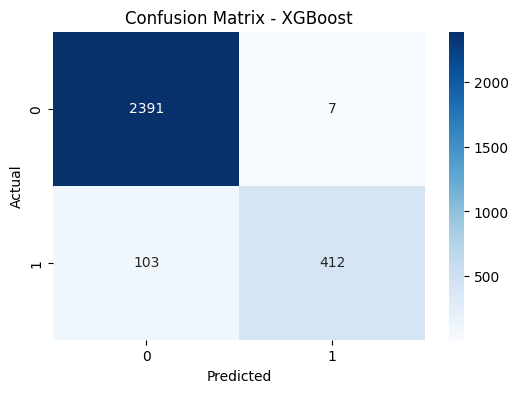

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [10]:
joblib.dump(xgb_model, r"models\churn_model_xgb.pkl")

['models\\churn_model_xgb.pkl']

In [11]:
feature_names = X.columns.tolist()
joblib.dump(feature_names, r"models\feature_names.pkl")
print("Feature Names Saved:", feature_names)

Feature Names Saved: ['Age', 'Policy_Tenure', 'Policy_Renewal_Count', 'Total_Claims_Filed', 'Claim_Amount_Total', 'Missed_Payments', 'Family_Members_Insured', 'Policy_Cancellation_History', 'Customer_Complaints', 'Complaint_Resolution_Time', 'Customer_Support_Calls', 'Vehicle_Age', 'Premium_Amount', 'Policy_Age', 'Policy_Duration', 'Time_Since_Last_Payment', 'Time_Since_Last_Claim', 'Gender_Female', 'Gender_Male', 'Marital_Status_Married', 'Marital_Status_Single', 'Region_Metro', 'Region_Rural', 'Region_Urban', 'Education_Level_Bachelor’s', 'Education_Level_Diploma', 'Education_Level_High School', 'Education_Level_Master’s', 'Employment_Status_Employed', 'Employment_Status_Self-Employed', 'Employment_Status_Unemployed', 'Policy_Type_Comprehensive', 'Policy_Type_Own Damage', 'Policy_Type_Third Party', 'Mode_of_Communication_Email', 'Mode_of_Communication_In-Person', 'Mode_of_Communication_Phone', 'Payment_Mode_Cash', 'Payment_Mode_Cheque', 'Payment_Mode_Credit Card', 'Payment_Mode_Onlin